# Deng flux reconstruction - Koppel-Martin Case 1, 2D point trace

Nonconforming 2D LCG solve on a unit-square quadrilateral bulk mesh
plus an independent 1D fracture mesh embedded in `gdim=2`, followed by
rectangular-cell Deng local post-processing.

This copy deliberately avoids `fenicsx_ii`: the Q1/P1/P0 saddle system is
assembled directly in PETSc, with `p_gamma` on a fine P1 fracture mesh and
`lambda_h` on a coarser P0 multiplier mesh.  The coupling terms use a codimension-1
pointwise trace of `p_m` on the fracture line, with no circle/disk average
and no `R_circle` parameter.  The reconstructed quantity is the 2D matrix
flux `Q = -k_m grad(p_m)`, so the old slab thickness and z-integration are
removed.


In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import ufl
import basix.ufl
from tqdm.auto import tqdm

from dolfinx import fem, geometry, mesh

comm = MPI.COMM_WORLD
rank = comm.rank
if comm.size != 1:
    raise RuntimeError("This manual point-trace assembly notebook is serial; run it with one MPI rank.")

np.random.seed(1234)

REF = 6
RUN_CONVERGENCE = False
CONV_REFS = [3, 4, 5, 6, 7]
ORDER = 1

K_M_VALUE = 1.0
K_F_VALUE = 10.0

# Koppel-Martin case 1 boundary-tip fracture.
FRAC_A = np.array([0.25, 0.0], dtype=float)
FRAC_B = np.array([0.75, 1.0], dtype=float)
TIP_FRAC = 0.05

OUTDIR = pathlib.Path("result_koppel_martin_case1_deng_2d_pointtrace")


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))

_G3 = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_W3 = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)
_G3_SYM = np.array([-np.sqrt(3.0 / 5.0), 0.0, np.sqrt(3.0 / 5.0)], dtype=float)
_W3_SYM = np.array([5.0 / 9.0, 8.0 / 9.0, 5.0 / 9.0], dtype=float)


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells)


def make_fracture_pressure_mesh(h):
    # Fracture pressure remains P1 on a relatively fine independent mesh.
    h_gamma_target = 0.5 * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_gamma + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_multiplier_mesh(h):
    # Koppel-Martin case-1 setting for P0 multipliers: h_lambda approx 2h.
    h_lambda_target = 2.0 * h
    n_lambda = max(1, int(round(L_gamma / h_lambda_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_lambda + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_nonconforming_meshes(ref):
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, h_gamma, n_gamma = make_fracture_pressure_mesh(h)
    gamma_l, h_lambda, n_lambda = make_multiplier_mesh(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_G3):
        for j, eta in enumerate(_G3):
            pts.append([xi, eta])
            weights.append(_W3[i] * _W3[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_coords[dofs],
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def q1_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    x0, x1, y0, y1 = cell["x0"], cell["x1"], cell["y0"], cell["y1"]
    hx, hy = cell["hx"], cell["hy"]
    vals = np.zeros((pts.shape[0], len(cell["dofs"])), dtype=float)
    grads = np.zeros((pts.shape[0], len(cell["dofs"]), 2), dtype=float)
    xmid = 0.5 * (x0 + x1)
    ymid = 0.5 * (y0 + y1)
    for a, xy in enumerate(cell["dof_xy"]):
        if xy[0] < xmid:
            px = (x1 - x) / hx
            dpx = np.full_like(x, -1.0 / hx)
        else:
            px = (x - x0) / hx
            dpx = np.full_like(x, 1.0 / hx)
        if xy[1] < ymid:
            py = (y1 - y) / hy
            dpy = np.full_like(y, -1.0 / hy)
        else:
            py = (y - y0) / hy
            dpy = np.full_like(y, 1.0 / hy)
        vals[:, a] = px * py
        grads[:, a, 0] = dpx * py
        grads[:, a, 1] = px * dpy
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


In [3]:
def assemble_bulk_stiffness(A, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        _, grads = q1_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)


def build_fracture_pressure_data(gamma, V_f):
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    cells = []
    s_nodes = []
    num_gamma_cells = gamma.topology.index_map(gamma.topology.dim).size_local
    for ci in range(num_gamma_cells):
        fdofs = np.asarray(V_f.dofmap.cell_dofs(ci), dtype=np.int32)
        s = s_coord_np(coords_f[fdofs])
        order = np.argsort(s)
        fdofs = fdofs[order]
        s = s[order]
        cells.append({"dofs": fdofs, "s0": float(s[0]), "s1": float(s[1])})
        s_nodes.extend([float(s[0]), float(s[1])])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    starts = np.array([c["s0"] for c in cells], dtype=float)
    order = np.argsort(starts)
    cells = [cells[i] for i in order]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_pressure_cell_s(s, pressure_data, tol=1e-12):
    cells = pressure_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def p1_line_basis_on_pressure_cell(cell, s):
    ell = cell["s1"] - cell["s0"]
    return np.array([(cell["s1"] - s) / ell, (s - cell["s0"]) / ell], dtype=float)


def line_mesh_cell_s_intervals(domain):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    coords = domain.geometry.x[:, :2]
    intervals = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s = np.sort(s_coord_np(coords[verts]))
        intervals.append((float(s[0]), float(s[1])))
    return intervals


def s_breakpoints(s0, s1, s_nodes, tol=1e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


def assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_fracture_pressure_data(gamma, V_f)

    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        ell = cell["s1"] - cell["s0"]
        Kloc = (K_F_VALUE / ell) * np.array([[1.0, -1.0], [-1.0, 1.0]], dtype=float)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)

    for ci, (s0, s1) in enumerate(line_mesh_cell_s_intervals(gamma_l)):
        ldofs = np.asarray(V_l.dofmap.cell_dofs(ci), dtype=np.int32)
        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        ell = float(np.linalg.norm(seg))

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, b in zip(pbreaks[:-1], pbreaks[1:]):
            if b - a <= 1e-14:
                continue
            pcell = locate_pressure_cell_s(0.5 * (a + b), pressure_data)
            fdofs = pcell["dofs"]
            for q, w in zip(_G3, _W3):
                sq = a + (b - a) * q
                psi = p1_line_basis_on_pressure_cell(pcell, sq)
                weight = (b - a) * w
                A.setValues(off_f + fdofs, off_l + ldofs, (weight * psi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, off_f + fdofs, (-weight * psi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)

        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            for q, w in zip(_G3, _W3):
                r = r0 + (r1 - r0) * q
                xq = xa + r * seg
                phi = q1_values_grads_on_cell(bulk_cell, xq[None, :])[0][0]
                weight = ell * (r1 - r0) * w
                A.setValues(mdofs, off_l + ldofs, (-weight * phi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, mdofs, (weight * phi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, off_l = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1e-12

    left = np.where(np.isclose(coords_m[:, 0], 0.0, atol=tol))[0].astype(np.int32)
    right = np.where(np.isclose(coords_m[:, 0], 1.0, atol=tol))[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")

    bc_idx = np.concatenate([off_m + left, off_m + right, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        np.full(len(left), 1.0),
        np.full(len(right), 4.0),
        np.array([1.0]),
        np.array([4.0]),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def solve_lcg_koppel_martin(ref=REF, order=ORDER, verbose=False):
    if order != 1:
        raise ValueError("The manual point-trace assembly is implemented for Q1/P1/P0 only.")
    omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", 1))
    V_f = fem.functionspace(gamma, ("Lagrange", 1))
    V_l = fem.functionspace(gamma_l, ("DG", 0))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    offsets = (0, n_m, n_m + n_f)
    n_total = n_m + n_f + n_l

    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)
    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=80, comm=comm)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    assemble_bulk_stiffness(A, bulk_data)
    assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets)
    A.assemble()

    b = A.createVecRight()
    b.set(0.0)
    b.assemble()
    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, offsets)
    A.assemble()

    x, factor_solver = solve_petsc_lu(A, b, prefix=f"km2d_ref{ref}_")
    arr = x.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = arr[offsets[0]:offsets[1]]
    p_f.x.array[:] = arr[offsets[1]:offsets[2]]
    lmbd.x.array[:] = arr[offsets[2]:offsets[2] + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    k_m = fem.Constant(omega, np.eye(2, dtype=np.float64))
    k_f = fem.Constant(gamma, K_F_VALUE)
    coords = omega.geometry.x
    xmin, xmax = float(coords[:, 0].min()), float(coords[:, 0].max())
    ymin, ymax = float(coords[:, 1].min()), float(coords[:, 1].max())

    if verbose:
        print(f"PETSc LU factor solver: {factor_solver}")
        print(
            f"n_bulk={n_bulk}, n_gamma={n_gamma}, n_lambda={n_lambda}, "
            f"h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda={h_lambda:.3e}"
        )
        print(f"dofs: matrix={n_m}, fracture={n_f}, lambda(P0)={n_l}, total={n_total}")

    return {
        "ref": int(ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "k_f": k_f,
        "h": float(h),
        "h_gamma": float(h_gamma),
        "h_lambda": float(h_lambda),
        "n_bulk": int(n_bulk),
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "bulk_data": bulk_data,
        "bbox": (xmin, xmax, ymin, ymax),
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_total": int(n_total),
        "factor_solver": factor_solver,
    }


t0 = time.perf_counter()
sol = solve_lcg_koppel_martin(REF, ORDER, verbose=True)
print(f"LCG solve complete in {time.perf_counter() - t0:.2f} s")
print(
    f"ref={sol['ref']} h={sol['h']:.3e} h_gamma={sol['h_gamma']:.3e} "
    f"h_lambda={sol['h_lambda']:.3e} n_gamma={sol['n_gamma']} "
    f"n_lambda={sol['n_lambda']} total dofs={sol['ndof_total']}"
)
omega = sol["omega"]; gamma = sol["gamma"]; gamma_l = sol["gamma_l"]
V_m = sol["V_m"]; V_f = sol["V_f"]; V_l = sol["V_l"]
p_m = sol["p_m"]; p_f = sol["p_f"]; lmbd = sol["lmbd"]; k_m = sol["k_m"]
h = sol["h"]; h_est = h
xmin, xmax, ymin, ymax = sol["bbox"]


PETSc LU factor solver: mumps
n_bulk=128, n_gamma=287, n_lambda=72, h=7.812e-03, h_gamma=3.896e-03, h_lambda=1.553e-02
dofs: matrix=16641, fracture=288, lambda(P0)=72, total=17001
LCG solve complete in 4.28 s
ref=6 h=7.812e-03 h_gamma=3.896e-03 h_lambda=1.553e-02 n_gamma=287 n_lambda=72 total dofs=17001


In [4]:
def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


tdim = omega.topology.dim
gdim = omega.geometry.dim
omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
omega_geometry = omega.geometry.x
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

# Actual 2D mesh-cell polygons, ordered counter-clockwise for geometry work.
cell_polys = [order_polygon_vertices(omega_geometry[verts, :2]) for verts in local_cell_vertices]
cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])


def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))


shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        key = edge_key(poly[j], poly[(j + 1) % len(poly)])
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))
print("2D quad cells:", num_cells, "unique edges:", len(shadow_edges))

Wq = fem.functionspace(omega, ("DG", ORDER, (gdim,)))
_q_pts = Wq.element.interpolation_points
q_cg_expr = fem.Expression(-ufl.dot(k_m, ufl.grad(p_m)), _q_pts)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)


def as_eval_points(points):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    return np.column_stack([points[:, :2], np.zeros(points.shape[0])])


_BBTREE_CACHE = {}


def _get_bbtree(domain):
    key = id(domain)
    tree = _BBTREE_CACHE.get(key)
    if tree is None:
        tree = geometry.bb_tree(domain, domain.topology.dim)
        _BBTREE_CACHE[key] = tree
    return tree


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_eval_points(points)
    tree = _get_bbtree(domain)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    vals = np.asarray(fun.eval(np.asarray(valid_points), np.asarray(valid_cells, dtype=np.int32)))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]


def f_numpy(points):
    pts = np.asarray(points)
    return np.zeros(pts.reshape(-1, pts.shape[-1]).shape[0], dtype=float)


2D quad cells: 16384 unique edges: 33024


In [5]:
def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box")
    return min(ts), max(ts)


t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np


def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))


def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1e-11):
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals


def lambda_raw_on_s(s_query):
    return eval_fem_function(lmbd, real_points_np(s_query), gamma_l).reshape(-1)


def multiplier_s_nodes():
    gamma_l.topology.create_connectivity(gamma_l.topology.dim, 0)
    c2v_l = gamma_l.topology.connectivity(gamma_l.topology.dim, 0)
    coords_l = gamma_l.geometry.x[:, :2]
    vals = []
    for ci in range(gamma_l.topology.index_map(gamma_l.topology.dim).size_local):
        verts = np.asarray(c2v_l.links(ci), dtype=np.int32)
        vals.extend(s_coord_np(coords_l[verts]))
    return np.unique(np.round(np.asarray(vals, dtype=float), 12))


_LAM_S_NODES = multiplier_s_nodes()
_GS2 = np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])


def _split_at_lambda_nodes(s0, s1, tol=1e-12):
    lo, hi = (s0, s1) if s0 <= s1 else (s1, s0)
    inner = _LAM_S_NODES[(_LAM_S_NODES > lo + tol) & (_LAM_S_NODES < hi - tol)]
    knots = np.concatenate(([lo], inner, [hi]))
    return list(zip(knots[:-1], knots[1:]))


def integrate_lambda_interval_raw(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_raw_on_s(sq))
    return float(total)


EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)


def integrate_flux_polygon(poly):
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            flux += w * np.dot(q_cg_numpy(pt[None, :])[0], n_len)
    return float(flux)


def integrate_cg_flux_cell_local(cell_id, poly=None):
    poly = cell_polys[int(cell_id)] if poly is None else poly
    bulk_cell = sol["bulk_data"]["cells"][int(cell_id)]
    uvals = p_m.x.array[bulk_cell["dofs"]]
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            _, grads = q1_values_grads_on_cell(bulk_cell, pt[None, :])
            grad = grads[0].T @ uvals
            flux += w * np.dot(-(K_M_VALUE) * grad, n_len)
    return float(flux)


lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    for s0, s1 in fracture_intervals_in_polygon(poly):
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

cell_flux_cg = np.array([
    integrate_cg_flux_cell_local(_cid, _poly) for _cid, _poly in enumerate(cell_polys)
], dtype=float)
cell_source = np.zeros(num_cells, dtype=float)

# The manual PETSc system is assembled with the weak-form signs in this notebook,
# so lambda enters the local balance directly as the line source.
LAMBDA_SIGN = 1.0
lambda_h_cell_int = lambda_h_cell_int_raw


def lambda_h_on_s(s_query):
    return LAMBDA_SIGN * lambda_raw_on_s(s_query)


print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with weak-form lambda sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with weak-form lambda sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))


fracture-cut cells: 128
LAMBDA_SIGN: 1.0
mean |R_CG| with weak-form lambda sign: 0.00016682485647834093
max  |R_CG| with weak-form lambda sign: 0.10866241886066262


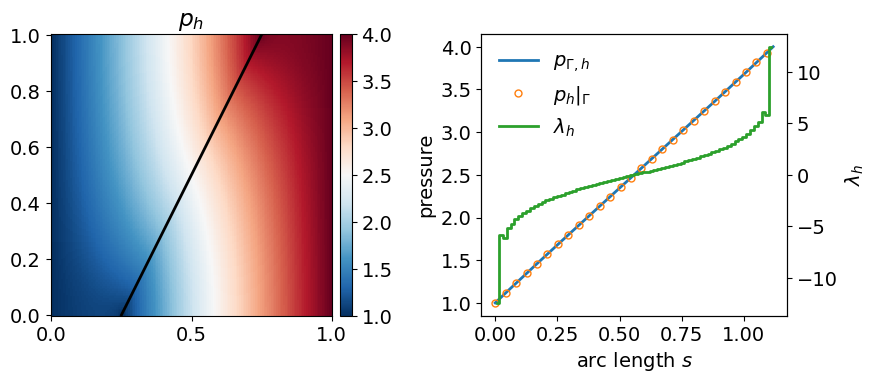

In [6]:
# ============================================================
# Pre-reconstruction visualization of the LCG solution
# ============================================================
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({"font.size": 14})

R_XI_MAP_FONTSIZE = 12
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# (a) matrix pressure p_h over the domain (with the fracture).
_nx = _ny = 160
_xg = np.linspace(xmin, xmax, _nx)
_yg = np.linspace(ymin, ymax, _ny)
_Xg, _Yg = np.meshgrid(_xg, _yg)
_P = eval_fem_function(p_m, np.column_stack([_Xg.ravel(), _Yg.ravel()]), omega).reshape(_ny, _nx)
_pc = axes[0].pcolormesh(_Xg, _Yg, _P, cmap="RdBu_r", shading="auto")
axes[0].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=2.0)
axes[0].set_aspect("equal")
# axes[0].set_xlabel("$x$")
# axes[0].set_ylabel("$y$")
axes[0].set_title("$p_h$")
# colorbar height tied to the domain [0,1]
_div = make_axes_locatable(axes[0])
_cax = _div.append_axes("right", size="4%", pad=0.08)
fig.colorbar(_pc, cax=_cax)

# (b) fracture pressure p_{Gamma,h}, matrix trace p_h|_Gamma, and multiplier
#     lambda_h along the fracture. lambda_h is on a different scale/sign, so it
#     uses a secondary y-axis.
_sf = s_coord_np(V_f.tabulate_dof_coordinates()[:, :2])
_of = np.argsort(_sf)
_s_dense = np.linspace(0.0, L_gamma, 400)
_p_trace = eval_fem_function(p_m, real_points_np(_s_dense), omega).reshape(-1)
_sl = s_coord_np(V_l.tabulate_dof_coordinates()[:, :2])
_ol = np.argsort(_sl)

axL = axes[1]
h1, = axL.plot(_sf[_of], p_f.x.array[_of], "-", lw=2.0, color="tab:blue", label=r"$p_{\Gamma,h}$")
h2, = axL.plot(_s_dense, _p_trace, "o", ms=5, mfc="none", color="tab:orange", markevery=15, label=r"$p_h|_\Gamma$")
axL.set_xlabel(r"arc length $s$")
axL.set_ylabel("pressure")

axR = axL.twinx()
h3, = axR.step(_sl[_ol], lmbd.x.array[_ol], where="mid", lw=2.0, color="tab:green", label=r"$\lambda_h$")
axR.set_ylabel(r"$\lambda_h$")

axL.legend(handles=[h1, h2, h3], frameon=False, loc="best")
fig.tight_layout()
plt.show()


In [7]:
# Rectangular Q1 helpers for the 2D Deng post-processing.
if ORDER != 1:
    print("Warning: Deng rectangular local solve is Q1-based; ORDER=1 is recommended.")


def q1_phi(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    return np.stack([
        (1.0 - xi) * (1.0 - eta),
        xi * (1.0 - eta),
        (1.0 - xi) * eta,
        xi * eta,
    ], axis=-1)


def q1_grad_ref(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    dxi = np.stack([-(1.0 - eta), (1.0 - eta), -eta, eta], axis=-1)
    deta = np.stack([-(1.0 - xi), -xi, (1.0 - xi), xi], axis=-1)
    return np.stack([dxi, deta], axis=-1)


def q1_grad_phys(xi_eta, hx, hy):
    g = q1_grad_ref(xi_eta).astype(float)
    g[..., 0] /= hx
    g[..., 1] /= hy
    return g


def ref_from_phys(cell, x):
    x0, y0 = cell["xy"][0]
    return np.array([(x[0] - x0) / cell["hx"], (x[1] - y0) / cell["hy"]], dtype=float)


def grad_from_coeffs(cell, coeffs, x):
    xi = ref_from_phys(cell, x)
    grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
    return grads.T @ coeffs


def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


def prepare_rect_data_from_quad_mesh():
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    dofmap = V_m.dofmap
    pvals = p_m.x.array
    vertex_key_to_id = {}
    vertices_xy = []
    cells = []

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, poly in enumerate(cell_polys):
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        corners = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        vids = np.array([get_vid(corner) for corner in corners], dtype=np.int32)
        u4 = np.zeros(4, dtype=float)
        cdofs = np.asarray(dofmap.cell_dofs(ci), dtype=np.int32)
        ccoords = dof_coords[cdofs]
        cvals = pvals[cdofs]
        for k, corner in enumerate(corners):
            dist = np.linalg.norm(ccoords - corner[None, :], axis=1)
            u4[k] = float(cvals[np.argmin(dist)])
        cells.append({
            "xy": corners,
            "poly": np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float),
            "vids": vids,
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "uvals": u4,
            "cell_id": ci,
        })

    edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)]
    edge_to_cells = {}
    for ci, cell in enumerate(cells):
        for e, (a, b) in enumerate(edge_defs):
            key = tuple(sorted((int(cell["vids"][a]), int(cell["vids"][b]))))
            edge_to_cells.setdefault(key, []).append((ci, e))
    vertices_xy = np.asarray(vertices_xy, dtype=float)
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell in enumerate(cells):
        for vid in cell["vids"]:
            vtc[int(vid)].append(ci)
    return {
        "cells": cells,
        "vertices_xy": vertices_xy,
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": len(cells),
        "num_vertices": len(vertices_xy),
    }


rect = prepare_rect_data_from_quad_mesh()
print("rectangular 2D cells:", rect["num_cells"], "vertices:", rect["num_vertices"])


rectangular 2D cells: 16384 vertices: 16641


In [8]:
def integrate_segment_basis_flux(cell, a, b, n_out):
    seg_len = edge_length(a, b)
    out = np.zeros(4, dtype=float)
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        xi = ref_from_phys(cell, x)
        grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
        out += w * (-(K_M_VALUE) * (grads @ n_out)) * seg_len
    return out


def local_kgrad_dot_n(cell, coeffs, x, n_out):
    grad = grad_from_coeffs(cell, coeffs, x)
    return float(np.dot(K_M_VALUE * grad, n_out))


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    cell = rect["cells"][ci]
    val = K_M_VALUE * grad_from_coeffs(cell, cell["uvals"], x)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        val_nb = K_M_VALUE * grad_from_coeffs(rect["cells"][nb], rect["cells"][nb]["uvals"], x)
        val = 0.5 * (val + val_nb)
    return float(np.dot(val, n_out))


def segment_flux(cell, coeffs, a, b, n_out):
    seg_len = edge_length(a, b)
    flux = 0.0
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        grad = grad_from_coeffs(cell, coeffs, x)
        flux += w * np.dot(-(K_M_VALUE) * grad, n_out) * seg_len
    return float(flux)


# Refresh the P0 multiplier-cell split points before the Deng local solves.
# The splitter itself is shared with the raw element lambda injection above.
_LAM_S_NODES = multiplier_s_nodes()

def integrate_lambda_phi_interval(cell, s0, s1):
    out = np.zeros(4, dtype=float)
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b); half = 0.5 * (b - a)
        sq = mid + half * _GS2
        pts = real_points_np(sq); lam = lambda_h_on_s(sq)
        for x, lv in zip(pts, lam):
            xi = ref_from_phys(cell, x)
            out += half * lv * q1_phi(xi[None, :])[0]
    return out

def integrate_lambda_interval_signed(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b); half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_h_on_s(sq))
    return float(total)


def deng_postprocess_rect_fracture(rect):
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}
    qp, qw = quad_points_weights()
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    dirichlet_tol = 1e-12

    for ci in tqdm(range(rect["num_cells"]), desc="Deng 2D rectangular local solves"):
        cell = rect["cells"][ci]
        xy = cell["xy"]
        hx, hy = cell["hx"], cell["hy"]
        area = hx * hy
        centroid = cell["centroid"]
        uvals = cell["uvals"]

        B = np.zeros((4, 4), dtype=float)
        source_t = np.zeros(4, dtype=float)
        source_phi = np.zeros(4, dtype=float)
        a_term = np.zeros(4, dtype=float)
        e_I = np.zeros(4, dtype=float)
        e_phi = np.zeros(4, dtype=float)

        grads_q = q1_grad_phys(qp, hx, hy)
        grad_u_q = np.einsum("qjd,j->qd", grads_q, uvals)
        a_term += area * np.einsum("q,qjd,qd->j", qw, K_M_VALUE * grads_q, grad_u_q)

        for gi in range(4):
            vi = xy[gi]
            vn = xy[next_ccw[gi]]
            vp = xy[prev_ccw[gi]]
            mid_next = 0.5 * (vi + vn)
            mid_prev = 0.5 * (vi + vp)
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)
            for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(cv_poly)):
                source_t[gi] += integrate_lambda_interval_signed(s0, s1)
            for midp in [mid_next, mid_prev]:
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                B[gi, :] += integrate_segment_basis_flux(cell, centroid, midp, n_seg)

        for s0, s1 in fracture_intervals_in_polygon(cell["poly"]):
            source_phi += integrate_lambda_phi_interval(cell, s0, s1)

        for (a_id, b_id) in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n_out = outward_edge_normal(a, b, centroid)
            edge_key_local = tuple(sorted((int(cell["vids"][a_id]), int(cell["vids"][b_id]))))
            seg_len = edge_length(a, b)
            for t, w in zip(_G3, _W3):
                x = a + t * (b - a)
                xi = ref_from_phys(cell, x)
                phi_edge = q1_phi(xi[None, :])[0]
                avg = averaged_kgrad_dot_n(rect, ci, edge_key_local, x, n_out)
                e_phi += w * avg * phi_edge * seg_len
            for gi, other in [(a_id, b_id), (b_id, a_id)]:
                half_end = 0.5 * (xy[gi] + xy[other])
                half_len = edge_length(xy[gi], half_end)
                for t, w in zip(_G3, _W3):
                    x = xy[gi] + t * (half_end - xy[gi])
                    avg = averaged_kgrad_dot_n(rect, ci, edge_key_local, x, n_out)
                    e_I[gi] += w * avg * half_len

        rhs = source_t - source_phi + a_term + e_I - e_phi
        fixed = {}
        for li, xyi in enumerate(xy):
            if abs(xyi[0]) < dirichlet_tol or abs(xyi[0] - 1.0) < dirichlet_tol:
                fixed[li] = uvals[li]

        A_loc = B.copy()
        bvec = rhs.copy()
        for lid, val in fixed.items():
            bvec -= A_loc[:, lid] * val
        free = [i for i in range(4) if i not in fixed]
        coeffs = np.zeros(4, dtype=float)
        for lid, val in fixed.items():
            coeffs[lid] = val
        if free:
            coeffs[np.asarray(free)] = np.linalg.lstsq(A_loc[:, free], bvec, rcond=None)[0]

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "rhs": rhs.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return local_fluxes, coef_glob, p_rec


t0 = time.perf_counter()
local_fluxes, coef_glob, p_rec = deng_postprocess_rect_fracture(rect)
print(f"Deng post-processing time: {time.perf_counter() - t0:.2f} s")


Deng 2D rectangular local solves:   0%|          | 0/16384 [00:00<?, ?it/s]

Deng 2D rectangular local solves: 100%|██████████| 16384/16384 [01:18<00:00, 208.86it/s]


Deng post-processing time: 78.52 s


In [9]:
def compute_lce_per_element_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        flux = 0.0
        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n = outward_edge_normal(a, b, centroid)
            flux += segment_flux(cell, coeffs, a, b, n)
        source = lambda_h_cell_int[cell["cell_id"]]
        R[ci] = flux - source
    return R

def compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        source_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            centroid = cell["centroid"]
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for midp in [mid_next, mid_prev]:
                n = normal_from_C_to_ti(centroid, midp, vi)
                flux_sum += segment_flux(cell, coeffs, centroid, midp, n)
            source_sum += local_fluxes[ci]["source_t"][gi]
        R[vid] = flux_sum - source_sum
    return R

def boundary_vertex_mask_rect(rect):
    xy = rect["vertices_xy"]
    tol = 1e-12
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )

def residual_stats(vals, ids=None):
    vals = np.asarray(vals if ids is None else vals[ids], dtype=float)
    return {
        "mean": float(np.mean(np.abs(vals))),
        "median": float(np.median(np.abs(vals))),
        "max": float(np.max(np.abs(vals))),
    }

R_elem_cg = compute_lce_per_element_rect(rect, local_fluxes, use_rec=False)
R_elem_rec = compute_lce_per_element_rect(rect, local_fluxes, use_rec=True)
R_cv_cg = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=False)
R_cv_rec = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True)
frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)
is_bnd = boundary_vertex_mask_rect(rect)
interior_vertex_ids = np.where(~is_bnd)[0]

print("Element-wise residual R_K")
print("  CG  :", residual_stats(R_elem_cg))
print("  Deng:", residual_stats(R_elem_rec))
print("Fracture-cut element residual R_K")
print("  CG  :", residual_stats(R_elem_cg, frac_cell_ids))
print("  Deng:", residual_stats(R_elem_rec, frac_cell_ids))
print("Interior control-volume residual R_xi")
print("  CG  :", residual_stats(R_cv_cg, interior_vertex_ids))
print("  Deng:", residual_stats(R_cv_rec, interior_vertex_ids))


Element-wise residual R_K
  CG  : {'mean': 0.00016682485647834147, 'median': 0.0, 'max': 0.10866241886066262}
  Deng: {'mean': 0.00016682485647834133, 'median': 0.0, 'max': 0.10866241886066262}
Fracture-cut element residual R_K
  CG  : {'mean': 0.021353581629227562, 'median': 0.01626225202173969, 'max': 0.10866241886066262}
  Deng: {'mean': 0.021353581629227562, 'median': 0.01626225202173969, 'max': 0.10866241886066262}
Interior control-volume residual R_xi
  CG  : {'mean': 2.045241517144419e-05, 'median': 4.506842192410904e-09, 'max': 0.007972975565354694}
  Deng: {'mean': 1.468124685285674e-15, 'median': 8.222589276130066e-16, 'max': 1.1544515343686612e-12}


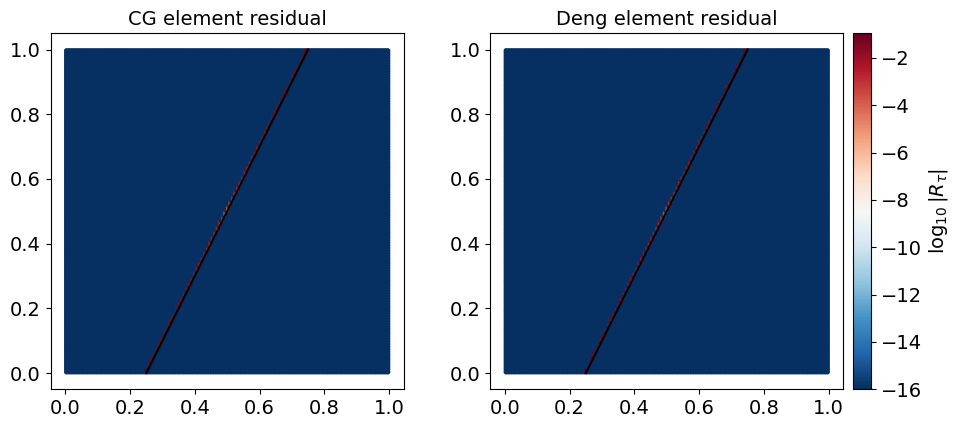

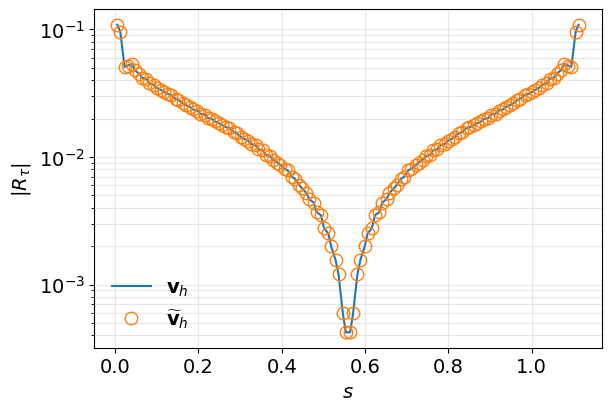

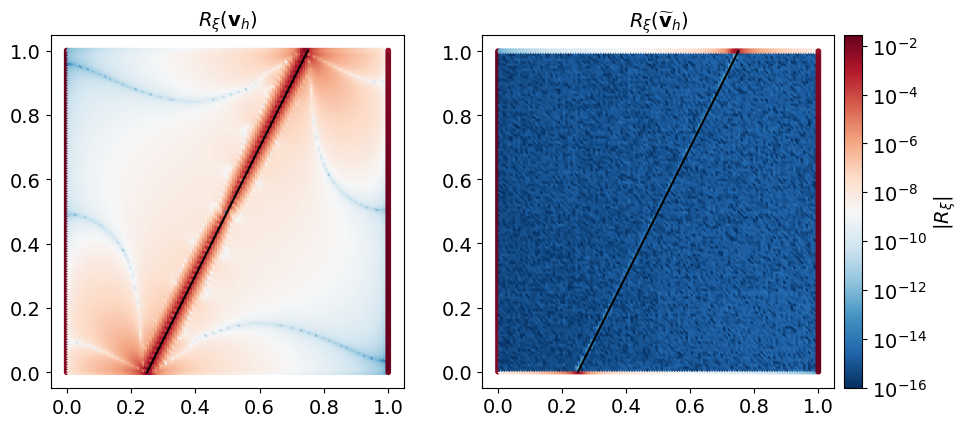

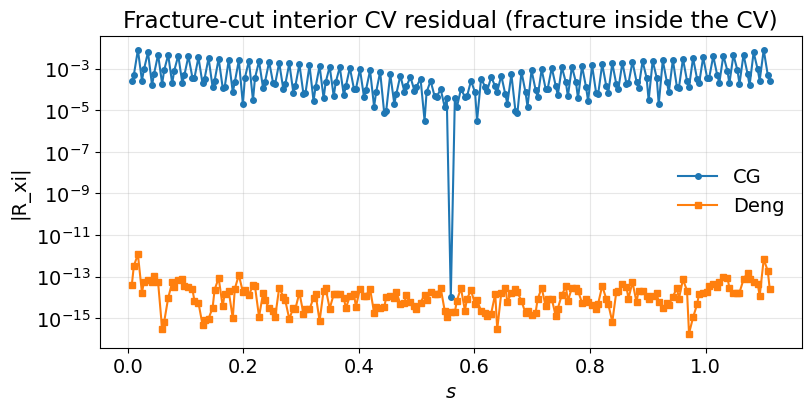

fracture-cut interior CVs: 191 | Deng |R_xi| median=1.12e-14 max=1.15e-12


In [10]:
eps = 1e-16
plt.rcParams.update({"font.size": 14})
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Guard against stale globals (e.g. left by an interrupted convergence sweep):
# the figures need the residual arrays to match the current rect.
if len(R_elem_cg) != rect["num_cells"] or len(R_cv_cg) != rect["num_vertices"]:
    if len(local_fluxes) != rect["num_cells"]:
        raise RuntimeError("rect/local_fluxes out of sync (likely an interrupted "
                           "convergence run). Re-run the single-case solve and "
                           "reconstruction cells, then this cell.")
    R_elem_cg = compute_lce_per_element_rect(rect, local_fluxes, use_rec=False)
    R_elem_rec = compute_lce_per_element_rect(rect, local_fluxes, use_rec=True)
    R_cv_cg = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=False)
    R_cv_rec = compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True)
    frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)
    is_bnd = boundary_vertex_mask_rect(rect)
    interior_vertex_ids = np.where(~is_bnd)[0]
cent = np.vstack([cell["centroid"] for cell in rect["cells"]])
R_XI_MAP_FONTSIZE = 14
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
_rk = np.log10(np.abs(np.concatenate([R_elem_cg, R_elem_rec])) + eps)
_vmin, _vmax = float(_rk.min()), float(_rk.max())
for ax, vals, title in [
    (axes[0], R_elem_cg, "CG element residual"),
    (axes[1], R_elem_rec, "Deng element residual"),
]:
    sc = ax.scatter(cent[:, 0], cent[:, 1], c=np.log10(np.abs(vals) + eps), s=8, cmap="RdBu_r", vmin=_vmin, vmax=_vmax)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=R_XI_MAP_FONTSIZE)
    ax.tick_params(labelsize=R_XI_MAP_FONTSIZE)
# single shared colorbar, height tied to the domain
_div = make_axes_locatable(axes[1])
_cax = _div.append_axes("right", size="5%", pad=0.1)
fig.colorbar(sc, cax=_cax, label=r"$\log_{10}|R_\tau|$")
fig.tight_layout()
plt.show()

if len(frac_cell_ids):
    s_frac = s_coord_np(cent[frac_cell_ids])
    idx = np.argsort(s_frac)
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.semilogy(s_frac[idx], np.abs(R_elem_cg[frac_cell_ids][idx]) + eps, "-", ms=6, color="tab:blue", label=r"$\mathbf{v}_h$")
    ax.semilogy(s_frac[idx], np.abs(R_elem_rec[frac_cell_ids][idx]) + eps, "o", ms=9, mfc="none", color="tab:orange", label=r"$\widetilde{\mathbf{v}}_h$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$|R_\tau|$")
    ax.legend(frameon=False)
    ax.grid(True, which="both", alpha=0.3)
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
xyv = rect["vertices_xy"]
R_XI_COLORBAR_TICK_PARITY = "even"  # "even", "odd", or "all"
_rx = np.log10(np.abs(np.concatenate([R_cv_cg, R_cv_rec])) + eps)
_vmin, _vmax = float(_rx.min()), float(_rx.max())
for ax, vals, title in [
    (axes[0], R_cv_cg, r"$R_\xi(\mathbf{v}_h)$"),
    (axes[1], R_cv_rec, r"$R_\xi(\widetilde{\mathbf{v}}_h)$"),
]:
    sc = ax.scatter(xyv[:, 0], xyv[:, 1], c=np.log10(np.abs(vals) + eps), s=10, cmap="RdBu_r", vmin=_vmin, vmax=_vmax)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=R_XI_MAP_FONTSIZE)
    ax.tick_params(labelsize=R_XI_MAP_FONTSIZE)
# single shared colorbar, height tied to the domain
_div = make_axes_locatable(axes[1])
_cax = _div.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(sc, cax=_cax)
cbar.set_label(r"$|R_\xi|$", fontsize=R_XI_MAP_FONTSIZE)
_tick_lo = int(np.floor(_vmin))
_tick_hi = int(np.ceil(_vmax))
_cb_ticks_all = np.arange(_tick_lo, _tick_hi + 1, 1)
if R_XI_COLORBAR_TICK_PARITY == "even":
    _cb_ticks = _cb_ticks_all[(_cb_ticks_all % 2) == 0]
elif R_XI_COLORBAR_TICK_PARITY == "odd":
    _cb_ticks = _cb_ticks_all[(_cb_ticks_all % 2) != 0]
else:
    _cb_ticks = _cb_ticks_all
_cb_ticks = _cb_ticks[(_cb_ticks >= _vmin) & (_cb_ticks <= _vmax)]
if len(_cb_ticks) == 0:
    _cb_ticks = _cb_ticks_all[(_cb_ticks_all >= _vmin) & (_cb_ticks_all <= _vmax)]
if len(_cb_ticks) == 0:
    _cb_ticks = np.array([_vmin, _vmax])
cbar.set_ticks(_cb_ticks)
cbar.set_ticklabels([rf"$10^{{{int(t)}}}$" for t in _cb_ticks])
cbar.ax.tick_params(labelsize=R_XI_MAP_FONTSIZE)
fig.tight_layout()
plt.show()

# R_xi along the fracture: ONLY control volumes the fracture actually passes
# through, i.e. CVs with a non-zero fracture source (source_t != 0). Adjacent
# fracture-free CVs (which are trivially machine-eps) are excluded so the plot
# shows the conservation of the genuinely fracture-cut control volumes.
cv_frac_src = np.zeros(rect["num_vertices"], dtype=float)
for _ci, _cell in enumerate(rect["cells"]):
    _st = local_fluxes[_ci]["source_t"]
    for _gi, _vid in enumerate(_cell["vids"]):
        cv_frac_src[int(_vid)] += abs(_st[_gi])
cut_vids = np.where(cv_frac_src > 1e-14)[0]
cut_vids = cut_vids[~is_bnd[cut_vids]]
if len(cut_vids):
    xyv = rect["vertices_xy"]
    s_cv = s_coord_np(xyv[cut_vids])
    idx = np.argsort(s_cv)
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.semilogy(s_cv[idx], np.abs(R_cv_cg[cut_vids][idx]) + eps, "o-", ms=4, label="CG")
    ax.semilogy(s_cv[idx], np.abs(R_cv_rec[cut_vids][idx]) + eps, "s-", ms=4, label="Deng")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("|R_xi|")
    ax.set_title("Fracture-cut interior CV residual (fracture inside the CV)")
    ax.legend(frameon=False)
    ax.grid(True, which="both", alpha=0.3)
    plt.show()
    print(f"fracture-cut interior CVs: {len(cut_vids)} | "
          f"Deng |R_xi| median={np.median(np.abs(R_cv_rec[cut_vids])):.2e} "
          f"max={np.abs(R_cv_rec[cut_vids]).max():.2e}")


Rotated rectangular transport-CV residual R_zeta
  zeta cells: 16744
  angle=45 deg, Hu=0.0078125, Hv=0.0078125, shift=(0.00242187, 0.00367187)
  CG  : {'mean': 0.0001264750695052766, 'median': 1.3323374745386612e-05, 'max': 0.04771616576696119}
  NLR : {'mean': 0.000116335519416158, 'median': 1.3279379022742167e-05, 'max': 0.053463101934442564}
Rotated rectangular transport-CV squared residual over all zeta CVs
  CG  : n=16744 sum(R_zeta^2)=2.176226e-02 RMSE=1.140046e-03
  NLR : n=16744 sum(R_zeta^2)=2.066268e-02 RMSE=1.110871e-03
Fracture-cut rotated rectangular transport-CV residual R_zeta
  CG  : {'mean': 0.005887256246117133, 'median': 0.003291884688519052, 'max': 0.04771616576696119}
  NLR : {'mean': 0.005895677920193895, 'median': 0.003021100979753516, 'max': 0.053463101934442564}


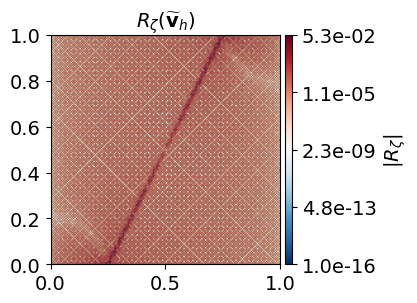

saved: result_koppel_martin_case1_deng_2d_pointtrace/R_zeta_NLR_rotated_cv.png


In [19]:
# Rotated rectangular transport-CV residual R_zeta for Deng/NLR reconstruction.
# This uses the same rotated CV geometry and log color scale as the PINN notebook.
from matplotlib.collections import PolyCollection

DENG_ZETA_ANGLE_DEG = 45.0
DENG_ZETA_HU = 1.0 * h_est
DENG_ZETA_HV = 1.0 * h_est
DENG_ZETA_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
DENG_ZETA_SHIFT_U = float(DENG_ZETA_SHIFT_FRACTION[0] * DENG_ZETA_HU)
DENG_ZETA_SHIFT_V = float(DENG_ZETA_SHIFT_FRACTION[1] * DENG_ZETA_HV)
DENG_ZETA_EDGE_NQ = 4
DENG_ZETA_SOURCE_NQ = 3
DENG_ZETA_MIN_AREA = 1.0e-14
DENG_ZETA_CMAP = "RdBu_r"
DENG_ZETA_OUTLINE_COLOR = "0.25"
DENG_ZETA_OUTLINE_WIDTH = 0.15
DENG_ZETA_LOG_CLIM = (-8.0, -1.0)
DENG_ZETA_FONTSIZE = 14
# False keeps the standalone panel colorbar-free for combining with the CG/PINN figure.
DENG_ZETA_SHOW_COLORBAR = True


def _zeta_legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [
        (0, xmin, False),
        (0, xmax, True),
        (1, ymin, False),
        (1, ymax, True),
    ]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def integrate_source_zeta_polygon(poly):
    if DENG_ZETA_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    poly = order_polygon_vertices(poly)
    p0 = poly[0]
    total = 0.0
    for i in range(1, len(poly) - 1):
        tri = np.array([p0, poly[i], poly[i + 1]], dtype=float)
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        if DENG_ZETA_SOURCE_NQ == 1:
            pts = tri.mean(axis=0, keepdims=True)
            weights = np.array([area], dtype=float)
        else:
            bary = np.array([[2.0 / 3.0, 1.0 / 6.0, 1.0 / 6.0],
                             [1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0],
                             [1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0]], dtype=float)
            pts = bary @ tri
            weights = np.full(3, area / 3.0, dtype=float)
        total += float(np.sum(f_numpy(pts) * weights))
    return total


def integrate_lambda_zeta_polygon_signed(poly):
    signed = 0.0
    unsigned = 0.0
    for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(poly)):
        piece = integrate_lambda_interval_signed(s0, s1)
        signed += piece
        unsigned += abs(piece)
    return float(signed), float(unsigned)


def zeta_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-zeta CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_zeta_cvs():
    theta = np.deg2rad(DENG_ZETA_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = zeta_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), DENG_ZETA_HU, DENG_ZETA_SHIFT_U)
    v_lines = zeta_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), DENG_ZETA_HV, DENG_ZETA_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= DENG_ZETA_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def build_zeta_cv_quadrature(polys):
    edge_q, edge_w = _zeta_legendre_01(DENG_ZETA_EDGE_NQ)
    edge_points, edge_nw, edge_eta_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for eid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[eid] = integrate_source_zeta_polygon(poly)
        frac_source[eid], frac_source_abs[eid] = integrate_lambda_zeta_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = bulk_breakpoints_on_segment(x0, x1, sol["bulk_data"])
            for a, b in zip(breaks[:-1], breaks[1:]):
                if b - a <= 1.0e-14:
                    continue
                xa = x0 + a * edge
                xb = x0 + b * edge
                seg = xb - xa
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                cell_id = int(locate_bulk_cell_xy(0.5 * (xa + xb), sol["bulk_data"])["cell_id"])
                for q, w in zip(edge_q, edge_w):
                    edge_points.append(xa + q * seg)
                    edge_nw.append(w * n_len)
                    edge_eta_ids.append(int(eid))
                    edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_eta_ids": np.asarray(edge_eta_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def prepare_rect_flux_arrays(rect, local_fluxes):
    n_cells = int(rect["num_cells"])
    x0 = np.empty(n_cells, dtype=float)
    y0 = np.empty(n_cells, dtype=float)
    hx = np.empty(n_cells, dtype=float)
    hy = np.empty(n_cells, dtype=float)
    cg_coeffs = np.empty((n_cells, 4), dtype=float)
    nlr_coeffs = np.empty((n_cells, 4), dtype=float)
    for cid, cell in enumerate(rect["cells"]):
        x0[cid], y0[cid] = cell["xy"][0]
        hx[cid] = cell["hx"]
        hy[cid] = cell["hy"]
        cg_coeffs[cid, :] = cell["uvals"]
        nlr_coeffs[cid, :] = local_fluxes[int(cid)]["coeffs"]
    return {
        "x0": x0,
        "y0": y0,
        "hx": hx,
        "hy": hy,
        "cg_coeffs": cg_coeffs,
        "nlr_coeffs": nlr_coeffs,
    }


rect_flux_arrays = prepare_rect_flux_arrays(rect, local_fluxes)


def q_rect_cell_local_numpy(points, cell_ids, use_rec):
    pts = np.asarray(points, dtype=float)
    cids = np.asarray(cell_ids, dtype=np.int32)
    a = rect_flux_arrays
    coeffs = a["nlr_coeffs" if use_rec else "cg_coeffs"][cids]
    hx = a["hx"][cids]
    hy = a["hy"][cids]
    xi = (pts[:, 0] - a["x0"][cids]) / hx
    eta = (pts[:, 1] - a["y0"][cids]) / hy
    c00 = coeffs[:, 0]
    c10 = coeffs[:, 1]
    c01 = coeffs[:, 2]
    c11 = coeffs[:, 3]
    grad_x = (-(1.0 - eta) * c00 + (1.0 - eta) * c10 - eta * c01 + eta * c11) / hx
    grad_y = (-(1.0 - xi) * c00 - xi * c10 + (1.0 - xi) * c01 + xi * c11) / hy
    return -K_M_VALUE * np.column_stack([grad_x, grad_y])


def compute_zeta_residuals(data, n_eta):
    q_cg = q_rect_cell_local_numpy(data["edge_points"], data["edge_cell_ids"], use_rec=False)
    q_deng = q_rect_cell_local_numpy(data["edge_points"], data["edge_cell_ids"], use_rec=True)
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_deng_q = np.sum(q_deng * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_eta, dtype=float)
    flux_deng = np.zeros(n_eta, dtype=float)
    np.add.at(flux_cg, data["edge_eta_ids"], flux_cg_q)
    np.add.at(flux_deng, data["edge_eta_ids"], flux_deng_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_deng - total_source


zeta_polys, zeta_centers, zeta_areas = build_rotated_zeta_cvs()
zeta_poly_counts = np.asarray([len(poly) for poly in zeta_polys], dtype=np.int32)
zeta_max_vertices = int(zeta_poly_counts.max()) if len(zeta_poly_counts) else 0
zeta_polys_padded = np.full((len(zeta_polys), zeta_max_vertices, 2), np.nan, dtype=float)
for _eid, _poly in enumerate(zeta_polys):
    zeta_polys_padded[_eid, :len(_poly), :] = _poly
zeta_data = build_zeta_cv_quadrature(zeta_polys)
R_zeta_cg, R_zeta_deng = compute_zeta_residuals(zeta_data, len(zeta_polys))
zeta_frac_ids = np.where(zeta_data["frac_source_abs"] > 1.0e-14)[0]

print("Rotated rectangular transport-CV residual R_zeta")
print(f"  zeta cells: {len(zeta_polys)}")
print(f"  angle={DENG_ZETA_ANGLE_DEG:.6g} deg, Hu={DENG_ZETA_HU:.6g}, Hv={DENG_ZETA_HV:.6g}, shift=({DENG_ZETA_SHIFT_U:.6g}, {DENG_ZETA_SHIFT_V:.6g})")
print("  CG  :", residual_stats(R_zeta_cg))
print("  NLR :", residual_stats(R_zeta_deng))


def zeta_squared_stats(vals):
    vals = np.asarray(vals, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return "n=0"
    sum_r2 = float(np.sum(vals ** 2))
    rmse = float(np.sqrt(sum_r2 / vals.size))
    return f"n={vals.size:d} sum(R_zeta^2)={sum_r2:.6e} RMSE={rmse:.6e}"

print("Rotated rectangular transport-CV squared residual over all zeta CVs")
print("  CG  :", zeta_squared_stats(R_zeta_cg))
print("  NLR :", zeta_squared_stats(R_zeta_deng))
if len(zeta_frac_ids):
    print("Fracture-cut rotated rectangular transport-CV residual R_zeta")
    print("  CG  :", residual_stats(R_zeta_cg, zeta_frac_ids))
    print("  NLR :", residual_stats(R_zeta_deng, zeta_frac_ids))

log_zeta_deng = np.log10(np.abs(R_zeta_deng) + eps)
if DENG_ZETA_SHOW_COLORBAR:
    _zeta_finite = log_zeta_deng[np.isfinite(log_zeta_deng)]
    if _zeta_finite.size == 0:
        _zeta_vmin, _zeta_vmax = map(float, DENG_ZETA_LOG_CLIM)
    else:
        _zeta_vmin = float(np.min(_zeta_finite))
        _zeta_vmax = float(np.max(_zeta_finite))
        if _zeta_vmin >= _zeta_vmax:
            _zeta_vmin -= 0.5
            _zeta_vmax += 0.5
else:
    _zeta_vmin, _zeta_vmax = map(float, DENG_ZETA_LOG_CLIM)

_fig_w = 3.65 if DENG_ZETA_SHOW_COLORBAR else 3.1
fig, ax = plt.subplots(figsize=(_fig_w, 3.1), constrained_layout=False)
if DENG_ZETA_SHOW_COLORBAR:
    fig.subplots_adjust(left=0.07, right=0.78, bottom=0.12, top=0.86)
else:
    fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86)
pc = PolyCollection(
    zeta_polys,
    edgecolors=DENG_ZETA_OUTLINE_COLOR,
    linewidths=DENG_ZETA_OUTLINE_WIDTH,
    cmap=DENG_ZETA_CMAP,
)
pc.set_array(log_zeta_deng)
pc.set_clim(_zeta_vmin, _zeta_vmax)
ax.add_collection(pc)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_title(r"$R_\zeta(\widetilde{\mathbf{v}}_h)$", fontsize=DENG_ZETA_FONTSIZE)
ax.tick_params(labelsize=DENG_ZETA_FONTSIZE)
ax.grid(False)
if DENG_ZETA_SHOW_COLORBAR:
    fig.canvas.draw()
    _pos = ax.get_position()
    _cax = fig.add_axes([_pos.x1 + 0.015, _pos.y0, 0.018, _pos.height])
    cbar = fig.colorbar(pc, cax=_cax)
    cbar.set_label(r"$|R_\zeta|$", fontsize=DENG_ZETA_FONTSIZE)
    _cb_ticks = np.linspace(_zeta_vmin, _zeta_vmax, 5)
    cbar.set_ticks(_cb_ticks)
    cbar.set_ticklabels([f"{10.0 ** float(t):.1e}" for t in _cb_ticks])
    cbar.ax.tick_params(labelsize=DENG_ZETA_FONTSIZE)
OUTDIR.mkdir(exist_ok=True)
fig.savefig(OUTDIR / "R_zeta_NLR_rotated_cv.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTDIR / "R_zeta_NLR_rotated_cv.pdf", bbox_inches="tight")
plt.show()
print("saved:", OUTDIR / "R_zeta_NLR_rotated_cv.png")


In [ ]:
outdir = OUTDIR
outdir.mkdir(exist_ok=True)
np.savez(
    outdir / "diagnostics.npz",
    centroids=np.vstack([cell["centroid"] for cell in rect["cells"]]),
    vertices=rect["vertices_xy"],
    R_elem_cg=R_elem_cg,
    R_elem_deng=R_elem_rec,
    R_cv_cg=R_cv_cg,
    R_cv_deng=R_cv_rec,
    zeta_polys=globals().get("zeta_polys_padded", np.zeros((0, 0, 2))),
    zeta_poly_counts=globals().get("zeta_poly_counts", np.array([], dtype=np.int32)),
    zeta_centers=globals().get("zeta_centers", np.zeros((0, 2))),
    zeta_areas=globals().get("zeta_areas", np.array([])),
    R_zeta_cg=globals().get("R_zeta_cg", np.array([])),
    R_zeta_deng=globals().get("R_zeta_deng", np.array([])),
    zeta_frac_ids=globals().get("zeta_frac_ids", np.array([], dtype=np.int32)),
    zeta_frac_source_abs=globals().get("zeta_data", {}).get("frac_source_abs", np.array([])),
    DENG_ZETA_ANGLE_DEG=globals().get("DENG_ZETA_ANGLE_DEG", np.nan),
    DENG_ZETA_HU=globals().get("DENG_ZETA_HU", np.nan),
    DENG_ZETA_HV=globals().get("DENG_ZETA_HV", np.nan),
    DENG_ZETA_SHIFT_U=globals().get("DENG_ZETA_SHIFT_U", np.nan),
    DENG_ZETA_SHIFT_V=globals().get("DENG_ZETA_SHIFT_V", np.nan),
    DENG_ZETA_LOG_CLIM=np.asarray(globals().get("DENG_ZETA_LOG_CLIM", (np.nan, np.nan)), dtype=float),
    frac_cell_ids=frac_cell_ids,
    p_rec=p_rec,
    LAMBDA_SIGN=LAMBDA_SIGN,
    h=sol["h"],
    h_gamma=sol["h_gamma"],
    h_lambda=sol["h_lambda"],
    FRAC_A=FRAC_A,
    FRAC_B=FRAC_B,
)
print("saved:", outdir)


## Convergence analysis

Köppel-Martin Case 1 has no manufactured exact solution in this notebook, so this section reports residual convergence versus mesh refinement: element-wise local balance, fracture-cut element balance, and interior control-volume balance before and after Deng reconstruction.


In [12]:
def convergence_rate(errors, hs):
    errors = np.asarray(errors, dtype=float)
    hs = np.asarray(hs, dtype=float)
    rates = [np.nan]
    for e0, e1, h0, h1 in zip(errors[:-1], errors[1:], hs[:-1], hs[1:]):
        if e0 > 0.0 and e1 > 0.0 and h0 > 0.0 and h1 > 0.0 and h0 != h1:
            rates.append(float(np.log(e0 / e1) / np.log(h0 / h1)))
        else:
            rates.append(np.nan)
    return rates


def fmt_rate(value):
    return "-" if not np.isfinite(value) else f"{value:.2f}"


def residual_stats_n(values, ids=None):
    vals = np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float)
    if vals.size == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    vals = np.abs(vals)
    return {
        "n": int(vals.size),
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "max": float(np.max(vals)),
    }


def fracture_vertex_ids_rect(rect_data, frac_ids, interior_ids):
    mask = np.zeros(rect_data["num_vertices"], dtype=bool)
    for ci in np.asarray(frac_ids, dtype=np.int32):
        mask[rect_data["cells"][int(ci)]["vids"]] = True
    return np.intersect1d(np.where(mask)[0], np.asarray(interior_ids, dtype=np.int32))


def activate_km_case(sol_case, order=ORDER, verbose=False):
    global sol, omega, gamma, gamma_l, V_m, V_f, V_l, p_m, p_f, lmbd, k_m, h, h_est
    global xmin, xmax, ymin, ymax, tdim, gdim, omega_geometry, num_cells, local_cell_vertices
    global cell_polys, cell_centroids, cell_areas, shadow_edges, Wq, q_cg_fun
    global t_min, t_max, GHOST_START, GHOST_END
    global lambda_h_cell_int_raw, gamma_facet_records, cell_flux_cg, cell_source
    global LAMBDA_SIGN, lambda_h_cell_int, rect, _LAM_S_NODES

    sol = sol_case
    omega = sol_case["omega"]
    gamma = sol_case["gamma"]
    gamma_l = sol_case["gamma_l"]
    V_m = sol_case["V_m"]
    V_f = sol_case["V_f"]
    V_l = sol_case["V_l"]
    p_m = sol_case["p_m"]
    p_f = sol_case["p_f"]
    lmbd = sol_case["lmbd"]
    k_m = sol_case["k_m"]
    h = sol_case["h"]
    h_est = h
    xmin, xmax, ymin, ymax = sol_case["bbox"]

    _BBTREE_CACHE.clear()
    tdim = omega.topology.dim
    gdim = omega.geometry.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    omega_geometry = omega.geometry.x
    num_cells = omega.topology.index_map(tdim).size_local
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts, :2]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])

    shadow_edges = []
    seen_edges = set()
    for poly in cell_polys:
        for j in range(len(poly)):
            key = edge_key(poly[j], poly[(j + 1) % len(poly)])
            if key not in seen_edges:
                seen_edges.add(key)
                shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    q_cg_expr = fem.Expression(-ufl.dot(k_m, ufl.grad(p_m)), Wq.element.interpolation_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
    GHOST_START = FRAC_A + t_min * tau_np
    GHOST_END = FRAC_A + t_max * tau_np

    _LAM_S_NODES = multiplier_s_nodes()

    lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
    gamma_facet_records = []
    for cell_id, poly in enumerate(cell_polys):
        for s0, s1 in fracture_intervals_in_polygon(poly):
            lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
            gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

    cell_flux_cg = np.array([
        integrate_cg_flux_cell_local(_cid, _poly) for _cid, _poly in enumerate(cell_polys)
    ], dtype=float)
    cell_source = np.zeros(num_cells, dtype=float)
    LAMBDA_SIGN = 1.0
    lambda_h_cell_int = lambda_h_cell_int_raw

    rect = prepare_rect_data_from_quad_mesh()
    if verbose:
        print("2D quad cells:", num_cells, "unique edges:", len(shadow_edges))
        print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
        print("LAMBDA_SIGN:", LAMBDA_SIGN)
    return rect


def run_deng_km_case(ref, order=ORDER, verbose=False):
    global local_fluxes, coef_glob, p_rec, R_elem_cg, R_elem_rec, R_cv_cg, R_cv_rec
    global frac_cell_ids, is_bnd, interior_vertex_ids

    wall0 = time.perf_counter()
    t0 = time.perf_counter()
    sol_case = solve_lcg_koppel_martin(ref, order, verbose=False)
    t_solve = time.perf_counter() - t0

    t1 = time.perf_counter()
    rect_case = activate_km_case(sol_case, order=order, verbose=verbose)
    t_geom = time.perf_counter() - t1

    t2 = time.perf_counter()
    local_fluxes, coef_glob, p_rec = deng_postprocess_rect_fracture(rect_case)
    t_post = time.perf_counter() - t2

    t3 = time.perf_counter()
    R_elem_cg = compute_lce_per_element_rect(rect_case, local_fluxes, use_rec=False)
    R_elem_rec = compute_lce_per_element_rect(rect_case, local_fluxes, use_rec=True)
    R_cv_cg = compute_lce_per_cv_rect(rect_case, local_fluxes, use_rec=False)
    R_cv_rec = compute_lce_per_cv_rect(rect_case, local_fluxes, use_rec=True)
    frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)
    is_bnd = boundary_vertex_mask_rect(rect_case)
    interior_vertex_ids = np.where(~is_bnd)[0]
    fracture_cv_ids = fracture_vertex_ids_rect(rect_case, frac_cell_ids, interior_vertex_ids)
    t_diag = time.perf_counter() - t3
    t_total = time.perf_counter() - wall0

    stats_elem_cg = residual_stats_n(R_elem_cg)
    stats_elem_rec = residual_stats_n(R_elem_rec)
    stats_elem_frac_cg = residual_stats_n(R_elem_cg, frac_cell_ids)
    stats_elem_frac_rec = residual_stats_n(R_elem_rec, frac_cell_ids)
    stats_cv_cg = residual_stats_n(R_cv_cg, interior_vertex_ids)
    stats_cv_rec = residual_stats_n(R_cv_rec, interior_vertex_ids)
    stats_cv_frac_cg = residual_stats_n(R_cv_cg, fracture_cv_ids)
    stats_cv_frac_rec = residual_stats_n(R_cv_rec, fracture_cv_ids)
    nonfrac_cv_ids = np.setdiff1d(interior_vertex_ids, fracture_cv_ids)
    stats_cv_bulk_cg = residual_stats_n(R_cv_cg, nonfrac_cv_ids)
    stats_cv_bulk_rec = residual_stats_n(R_cv_rec, nonfrac_cv_ids)

    return {
        "ref": int(ref),
        "h": float(sol_case["h"]),
        "h_gamma": float(sol_case["h_gamma"]),
        "h_lambda": float(sol_case["h_lambda"]),
        "n_gamma": int(sol_case["n_gamma"]),
        "n_lambda": int(sol_case["n_lambda"]),
        "dofs_total": int(sol_case["ndof_total"]),
        "num_cells": int(rect_case["num_cells"]),
        "num_vertices": int(rect_case["num_vertices"]),
        "num_frac_cells": int(len(frac_cell_ids)),
        "num_frac_cvs": int(len(fracture_cv_ids)),
        "mean_elem_cg": stats_elem_cg["mean"],
        "mean_elem_rec": stats_elem_rec["mean"],
        "max_elem_cg": stats_elem_cg["max"],
        "max_elem_rec": stats_elem_rec["max"],
        "mean_elem_frac_cg": stats_elem_frac_cg["mean"],
        "mean_elem_frac_rec": stats_elem_frac_rec["mean"],
        "max_elem_frac_cg": stats_elem_frac_cg["max"],
        "max_elem_frac_rec": stats_elem_frac_rec["max"],
        "mean_cv_cg": stats_cv_cg["mean"],
        "mean_cv_rec": stats_cv_rec["mean"],
        "max_cv_cg": stats_cv_cg["max"],
        "max_cv_rec": stats_cv_rec["max"],
        "mean_cv_frac_cg": stats_cv_frac_cg["mean"],
        "mean_cv_frac_rec": stats_cv_frac_rec["mean"],
        "max_cv_frac_cg": stats_cv_frac_cg["max"],
        "max_cv_frac_rec": stats_cv_frac_rec["max"],
        "median_cv_cg": stats_cv_cg["median"],
        "median_cv_rec": stats_cv_rec["median"],
        "mean_cv_bulk_rec": stats_cv_bulk_rec["mean"],
        "median_cv_bulk_rec": stats_cv_bulk_rec["median"],
        "max_cv_bulk_rec": stats_cv_bulk_rec["max"],
        "median_cv_frac_rec": stats_cv_frac_rec["median"],
        "num_bulk_cvs": int(len(nonfrac_cv_ids)),
        "lambda_sign": float(LAMBDA_SIGN),
        "t_solve": float(t_solve),
        "t_geom": float(t_geom),
        "t_post": float(t_post),
        "t_diag": float(t_diag),
        "t_total": float(t_total),
    }


def run_convergence_study(refs=CONV_REFS, order=ORDER):
    rows = []
    for ref in refs:
        print(f"ref={ref} ...", flush=True)
        row = run_deng_km_case(ref, order=order, verbose=False)
        rows.append(row)
        print(
            f"  h={row['h']:.3e}, h_gamma={row['h_gamma']:.3e}, h_lambda={row['h_lambda']:.3e}, "
            f"mean fracture R_xi^D={row['mean_cv_frac_rec']:.3e}, "
            f"median fracture R_xi^D={row['median_cv_frac_rec']:.3e}, total={row['t_total']:.2f}s"
        )
    return rows


if RUN_CONVERGENCE:
    conv_results = run_convergence_study(CONV_REFS, ORDER)
else:
    print("RUN_CONVERGENCE = False. Set it to True and rerun this cell for the convergence analysis.")


RUN_CONVERGENCE = False. Set it to True and rerun this cell for the convergence analysis.


In [13]:
hs = [r["h"] for r in conv_results]
rate_elem_cg = convergence_rate([r["mean_elem_cg"] for r in conv_results], hs)
rate_elem_rec = convergence_rate([r["mean_elem_rec"] for r in conv_results], hs)
rate_cv_cg = convergence_rate([r["mean_cv_cg"] for r in conv_results], hs)
rate_cv_rec = convergence_rate([r["mean_cv_rec"] for r in conv_results], hs)
rate_elem_frac_rec = convergence_rate([r["mean_elem_frac_rec"] for r in conv_results], hs)
rate_cv_frac_rec = convergence_rate([r["mean_cv_frac_rec"] for r in conv_results], hs)
rate_cv_frac_med = convergence_rate([r["median_cv_frac_rec"] for r in conv_results], hs)

print("\nKoppel-Martin Case 1 residual convergence, 2D point trace")
print("No exact solution is used here; rates are for residual diagnostics versus h.")
header = (
    f"{'ref':>3} {'h':>10} {'dofs':>8} "
    f"{'mean|R_K CG|':>14} {'rt':>5} "
    f"{'mean|R_K D|':>14} {'rt':>5} "
    f"{'mean|R_xi CG|':>15} {'rt':>5} "
    f"{'mean|R_xi D|':>14} {'rt':>5} {'total[s]':>10}"
)
print(header)
print("-" * len(header))
for i, r in enumerate(conv_results):
    print(
        f"{r['ref']:3d} {r['h']:10.3e} {r['dofs_total']:8d} "
        f"{r['mean_elem_cg']:14.3e} {fmt_rate(rate_elem_cg[i]):>5} "
        f"{r['mean_elem_rec']:14.3e} {fmt_rate(rate_elem_rec[i]):>5} "
        f"{r['mean_cv_cg']:15.3e} {fmt_rate(rate_cv_cg[i]):>5} "
        f"{r['mean_cv_rec']:14.3e} {fmt_rate(rate_cv_rec[i]):>5} {r['t_total']:10.3f}"
    )

print("\nRequested fracture-CV Deng residual convergence")
header = (
    f"{'ref':>3} {'h':>10} {'h_gamma':>10} {'h_lambda':>10} {'frac CVs':>9} "
    f"{'mean|R_xi^D|':>15} {'rt':>5} {'median|R_xi^D|':>17} {'rt':>5} {'max|R_xi^D|':>14}"
)
print(header)
print("-" * len(header))
for i, r in enumerate(conv_results):
    print(
        f"{r['ref']:3d} {r['h']:10.3e} {r['h_gamma']:10.3e} {r['h_lambda']:10.3e} {r['num_frac_cvs']:9d} "
        f"{r['mean_cv_frac_rec']:15.3e} {fmt_rate(rate_cv_frac_rec[i]):>5} "
        f"{r['median_cv_frac_rec']:17.3e} {fmt_rate(rate_cv_frac_med[i]):>5} "
        f"{r['max_cv_frac_rec']:14.3e}"
    )

print("\nFracture-cut element Deng residual convergence")
header = f"{'ref':>3} {'h':>10} {'frac cells':>10} {'mean|R_K^D|':>14} {'rt':>5} {'max|R_K^D|':>14}"
print(header)
print("-" * len(header))
for i, r in enumerate(conv_results):
    print(
        f"{r['ref']:3d} {r['h']:10.3e} {r['num_frac_cells']:10d} "
        f"{r['mean_elem_frac_rec']:14.3e} {fmt_rate(rate_elem_frac_rec[i]):>5} "
        f"{r['max_elem_frac_rec']:14.3e}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].loglog(hs, [r["mean_elem_cg"] for r in conv_results], "o-", label="mean |R_K(v_h)|")
axes[0].loglog(hs, [r["mean_elem_rec"] for r in conv_results], "s-", label="mean |R_K(v_D)|")
axes[0].loglog(hs, [r["mean_cv_cg"] for r in conv_results], "o--", label="mean |R_xi(v_h)|")
axes[0].loglog(hs, [r["mean_cv_rec"] for r in conv_results], "s--", label="mean |R_xi(v_D)|")
axes[0].invert_xaxis()
axes[0].set_xlabel("h")
axes[0].set_ylabel("mean residual")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].loglog(hs, [r["mean_cv_frac_cg"] for r in conv_results], "o--", label="fracture CVs R_xi(v_h)")
axes[1].loglog(hs, [r["mean_cv_frac_rec"] for r in conv_results], "s--", label="fracture CVs R_xi(v_D)")
axes[1].loglog(hs, [r["median_cv_frac_rec"] for r in conv_results], "v:", label="fracture CVs median R_xi(v_D)")
axes[1].invert_xaxis()
axes[1].set_xlabel("h")
axes[1].set_ylabel("fracture-CV residual")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(frameon=False)
plt.show()

conv_outdir = OUTDIR
conv_outdir.mkdir(exist_ok=True)
np.savez(conv_outdir / "convergence_residuals.npz", **{k: np.array([r[k] for r in conv_results]) for k in conv_results[0]})
print("saved:", conv_outdir / "convergence_residuals.npz")


NameError: name 'conv_results' is not defined